In [ ]:
# ==============================
# 0. 라이브러리 불러오기
# ==============================
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
# ==============================
# 0-1. 한글 폰트 설정 (Windows)
# ==============================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# ==============================
# 1. 데이터 불러오기
# ==============================
csv_path = r'C:\Users\green\python_jungsuk\training_data.csv'
df = pd.read_csv(csv_path)

In [ ]:
# ==============================
# 2. 파생 변수 생성
# ==============================
df['신청금액_연봉비율'] = df['신청금액'] / (df['연봉'] + 1)
df['신청금액_재산비율'] = df['신청금액'] / (df['재산'] + 1)
df['총자산'] = df['연봉'] + df['재산'] + df['예금']
df['자동차보유'] = (df['자동차배기량'] > 0).astype(int)
df['월상환추정'] = df['신청금액'] / (df['신청기간월'] + 1)

In [ ]:
# ==============================
# 3. 특징/타겟 설정
# ==============================
feature_cols = [c for c in df.columns if c != '승인여부']
X = df[feature_cols]
y = df['승인여부']

In [ ]:
# ==============================
# 4. 데이터 분할
# ==============================
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
# ==============================
# 5. 스케일링
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# ==============================
# 6. 모델 정의
# ==============================
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

print("진짜 실행 확인")


진짜 실행 확인


In [40]:
models = {
     'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
}

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [42]:
# ==============================
# 7. 교차검증
# ==============================
cv_results = {}
for name, model in models.items():
    result = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy': result['test_accuracy'].mean(),
        'Precision': result['test_precision'].mean(),
        'Recall': result['test_recall'].mean(),
        'F1': result['test_f1'].mean(),
        'ROC-AUC': result['test_roc_auc'].mean()
    }

In [45]:
cv_df = pd.DataFrame(cv_results).T.round(4)
print("\n교차검증 결과:")
print(cv_df)


교차검증 결과:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8785     0.9515  0.8739  0.9110   0.9540
Random Forest          0.8770     0.8973  0.9343  0.9154   0.9464


In [46]:
# ==============================
# 8. 상위 2개 모델 선택 (F1 기준)
# ==============================
top2 = cv_df['F1'].nlargest(2).index.tolist()
print(f'\n튜닝 대상 모델: {top2}')


튜닝 대상 모델: ['Random Forest', 'Logistic Regression']


In [47]:
# ==============================
# 9. 하이퍼파라미터 공간 정의
# ==============================
param_spaces = {
    'Logistic Regression': {'C': uniform(0.01, 100), 'penalty': ['l1','l2'], 'solver': ['saga']},
    'Random Forest': {'n_estimators': randint(100,500), 'max_depth':[None,10,20,30,50],
                      'min_samples_split': randint(2,20), 'min_samples_leaf': randint(1,10),
                      'max_features':['sqrt','log2', None]},
    'XGBoost': {'n_estimators': randint(100,500), 'max_depth': randint(3,15),
                'learning_rate': uniform(0.01,0.3), 'subsample': uniform(0.6,0.4),
                'colsample_bytree': uniform(0.6,0.4), 'min_child_weight': randint(1,10), 'gamma': uniform(0,5)},
    'LightGBM': {'n_estimators': randint(100,500), 'max_depth': randint(3,15),
                 'learning_rate': uniform(0.01,0.3), 'subsample': uniform(0.6,0.4),
                 'colsample_bytree': uniform(0.6,0.4), 'num_leaves': randint(20,100), 'min_child_samples': randint(5,50)}
}

In [48]:
# ==============================
# 10. 상위 2개 모델 튜닝
# ==============================
tuned_models = {}
tuned_cv_results = {}

In [49]:
for name in top2:
    print(f'\n=== {name} 튜닝 중 ===')
    base_model = models[name]
    search = RandomizedSearchCV(base_model, param_spaces[name], n_iter=5, scoring='f1',
                                cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
    search.fit(X_train_scaled, y_train)
    tuned_models[name] = search.best_estimator_
    tuned_cv_results[name] = search.best_score_
    print(f'Best F1: {search.best_score_:.4f}')
    print(f'Best Params: {search.best_params_}')


=== Random Forest 튜닝 중 ===
Best F1: 0.9184
Best Params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 413}

=== Logistic Regression 튜닝 중 ===
Best F1: 0.9112
Best Params: {'C': np.float64(37.464011884736244), 'penalty': 'l1', 'solver': 'saga'}


In [53]:
# ==============================
# 11. 튜닝 전후 비교 (상위 2개 모델만)
# ==============================
comparison = pd.DataFrame({
    '튜닝 전 F1': [cv_df.loc[name, 'F1'] for name in top2],
    '튜닝 후 F1': [tuned_cv_results[name] for name in top2]
}, index=top2)
comparison['개선폭'] = comparison['튜닝 후 F1'] - comparison['튜닝 전 F1']

In [54]:
print("\n튜닝 전후 비교")
print(comparison)


튜닝 전후 비교
                     튜닝 전 F1   튜닝 후 F1       개선폭
Random Forest         0.9154  0.918378  0.002978
Logistic Regression   0.9110  0.911198  0.000198


In [55]:
# ==============================
# 12. 전체 모델 학습
# ==============================
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

In [56]:
# 전체 모델(기본 + 튜닝) 테스트 성능 비교
all_models = {}
for name, model in models.items():
    all_models[f'{name} (기본)'] = model
for name, model in tuned_models.items():
    all_models[f'{name} (튜닝)'] = model

In [57]:
test_results = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }

In [58]:
test_df = pd.DataFrame(test_results).T.round(4)
test_df = test_df.sort_values('F1', ascending=False)
print("\n테스트셋 성능 비교:")
print(test_df)


테스트셋 성능 비교:
                          Accuracy  Precision  Recall      F1  ROC-AUC
Random Forest (기본)           0.881     0.9112  0.9228  0.9170   0.9454
Random Forest (튜닝)           0.878     0.9300  0.8961  0.9127   0.9472
Logistic Regression (기본)     0.869     0.9462  0.8652  0.9039   0.9458
Logistic Regression (튜닝)     0.869     0.9462  0.8652  0.9039   0.9457


In [59]:
# ==============================
# 13. 최적 모델 혼동행렬 시각화
# ==============================
best_name = test_df.index[0]
best_model = all_models[best_name]
print(f'\n최적 모델: {best_name} (F1={test_df.loc[best_name, "F1"]:.4f})')


최적 모델: Random Forest (기본) (F1=0.9170)


In [60]:
y_pred_best = best_model.predict(X_test_scaled)

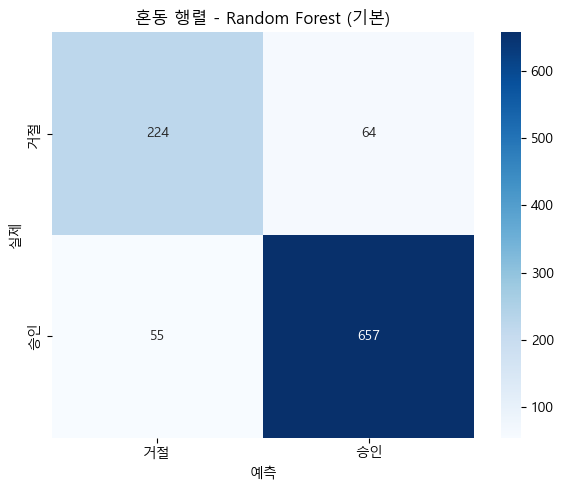

In [61]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['거절', '승인'], yticklabels=['거절', '승인'])
ax.set_xlabel('예측')
ax.set_ylabel('실제')
ax.set_title(f'혼동 행렬 - {best_name}')
plt.tight_layout()
plt.show()

In [62]:
# 최적 모델 분류 보고서
print(f'=== {best_name} 분류 보고서 ===')
print(classification_report(y_test, y_pred_best, target_names=['거절', '승인']))

=== Random Forest (기본) 분류 보고서 ===
              precision    recall  f1-score   support

          거절       0.80      0.78      0.79       288
          승인       0.91      0.92      0.92       712

    accuracy                           0.88      1000
   macro avg       0.86      0.85      0.85      1000
weighted avg       0.88      0.88      0.88      1000



In [63]:
# 피처 중요도 시각화
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

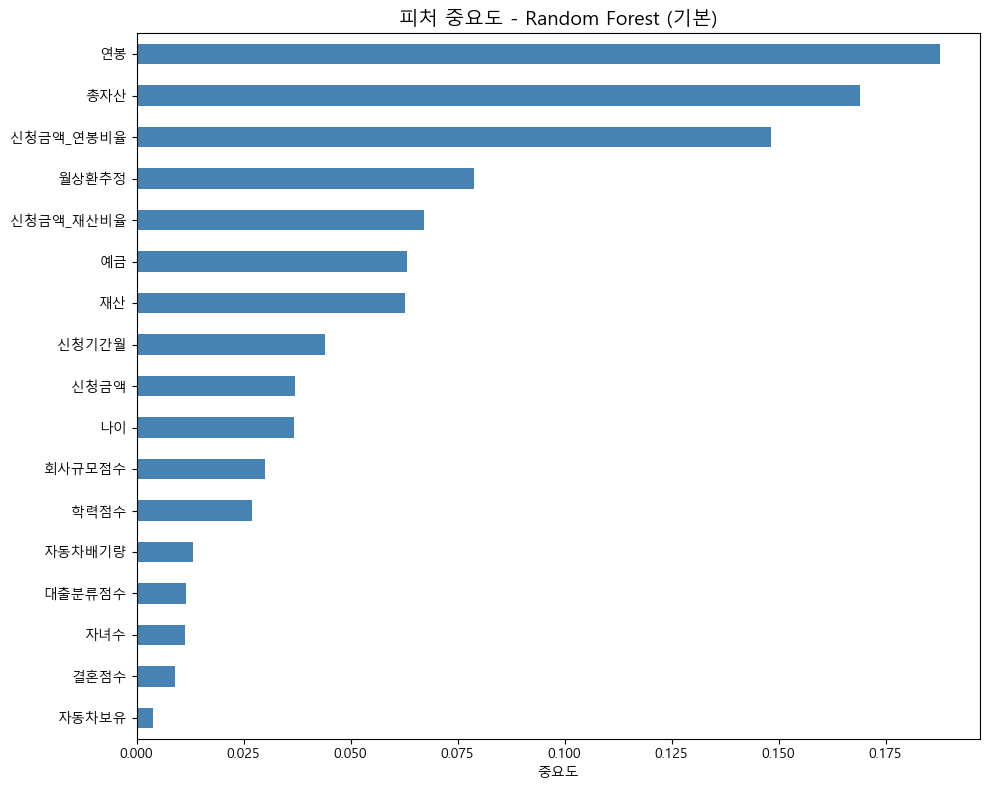

['scaler.joblib']

In [64]:
if importances is not None:
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'피처 중요도 - {best_name}', fontsize=14)
    ax.set_xlabel('중요도')
    plt.tight_layout()
    plt.show()

    # 모델, 스케일러, 메타데이터 저장
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

In [65]:
metadata = {
    'model_name': best_name,
    'feature_cols': feature_cols,
    'test_f1': test_df.loc[best_name, 'F1'],
    'test_auc': test_df.loc[best_name, 'ROC-AUC'],
    'test_results': test_df.to_dict(),
}
joblib.dump(metadata, 'model_metadata.joblib')

['model_metadata.joblib']

In [66]:
print('저장 완료: best_model.joblib, scaler.joblib, model_metadata.joblib')

저장 완료: best_model.joblib, scaler.joblib, model_metadata.joblib


In [67]:
# 로드 후 예측 일치 검증
loaded_model = joblib.load('best_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
loaded_meta = joblib.load('model_metadata.joblib')

In [68]:
X_test_reloaded = loaded_scaler.transform(X_test)
y_pred_reloaded = loaded_model.predict(X_test_reloaded)

In [69]:
match = np.array_equal(y_pred_best, y_pred_reloaded)
print(f'모델명: {loaded_meta["model_name"]}')
print(f'테스트 F1: {loaded_meta["test_f1"]:.4f}')
print(f'테스트 AUC: {loaded_meta["test_auc"]:.4f}')
print(f'예측 일치 검증: {"PASS" if match else "FAIL"}')

모델명: Random Forest (기본)
테스트 F1: 0.9170
테스트 AUC: 0.9454
예측 일치 검증: PASS


In [70]:
python -m notebook

SyntaxError: invalid syntax (2073583701.py, line 1)